# Evaluation Notebook 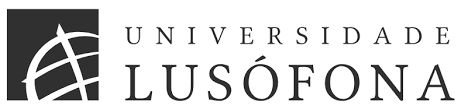 
## <font color='seablue'>**Benchmarking LLMs on Project Management**</font>
### <font color='black'>**Assessing Results**</font>
#### <font color='grey'> *João Caldeira @ 2025*</font>
This Notebook assesses multiple results of LLMs in the context of Project Management.
<hr>

# Setup

In [1]:
#!pip install matplotlib
#!pip install seaborn 
#!pip install scipy
#!pip install krippendorff
#!pip install sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from scipy import stats
from scipy.stats import rankdata
import krippendorff

In [2]:
# Plot dataframes side by side to avoid scrolling
from IPython.display import display, HTML
def plot_dataframes_side_by_side( dfs:list, captions:list, tablespacing=5 ):
    """Display tables side by side to save vertical space
    Input:
        dfs: list of pandas.DataFrame
        captions: list of table captions
    """
    output = ""
    for (caption, df) in zip(captions, dfs):
        output += df.style.set_table_attributes("style='display:inline'").set_caption(caption)._repr_html_()
        output += tablespacing * "\xa0"
    display(HTML(output))

In [3]:
import pandas as pd
from statistics import mode

def aggregate_groups( df, agg="mode"):
    """
    Aggregate AA, NA, and LLMx columns considering discrete ordinal values.
    Options for agg: "median", "mode", "sum"
    """
    aa_cols = [c for c in df.columns if c.startswith("AA_")]
    na_cols = [c for c in df.columns if c.startswith("NA_")]
    llm1_cols = [c for c in df.columns if c.startswith("LLM1_")]
    llm2_cols = [c for c in df.columns if c.startswith("LLM2_")]

    agg_df = df.copy()

    if agg == "median":
        agg_df["AA_Total"] = df[aa_cols].median(axis=1)
        agg_df["NA_Total"] = df[na_cols].median(axis=1)
        agg_df["LLM1_Total"] = df[llm1_cols].median(axis=1)
        agg_df["LLM2_Total"] = df[llm2_cols].median(axis=1)

    elif agg == "mode":
        agg_df["AA_Total"] = df[aa_cols].apply(lambda row: mode(row), axis=1)
        agg_df["NA_Total"] = df[na_cols].apply(lambda row: mode(row), axis=1)
        agg_df["LLM1_Total"] = df[llm1_cols].apply(lambda row: mode(row), axis=1)
        agg_df["LLM2_Total"] = df[llm2_cols].apply(lambda row: mode(row), axis=1)

    elif agg == "sum":
        agg_df["AA_Total"] = df[aa_cols].sum(axis=1)
        agg_df["NA_Total"] = df[na_cols].sum(axis=1)
        agg_df["LLM1_Total"] = df[llm1_cols].sum(axis=1)
        agg_df["LLM2_Total"] = df[llm2_cols].sum(axis=1)

    else:
        raise ValueError("agg must be 'median', 'mode', or 'sum'")

    return agg_df[["model","project","question","AA_Total","NA_Total","LLM1_Total","LLM2_Total"]]


In [4]:
def compute_kendall_w(df_subset):
    """Compute Kendall's W for ordinal rankings. Ensures 2D array input."""
    data = np.atleast_2d(df_subset.values)  # ensure 2D
    if data.shape[0] == 1 and data.shape[1] == 1:
        return np.nan  # not enough data to compute concordance

    # If columns < 2 (i.e., only one judge), return NaN
    if data.shape[1] < 2:
        return np.nan

    n_items, n_judges = data.shape
    ranks = np.array([rankdata(col) for col in data.T]).T
    sum_ranks = np.sum(ranks, axis=1)
    S = np.sum((sum_ranks - np.mean(sum_ranks))**2)
    W = 12 * S / (n_judges**2 * (n_items**3 - n_items))
    return W

In [5]:
def safe_krippendorff_alpha(df_subset):
    """
    Compute Krippendorff's alpha safely.
    Returns NaN if there is only one row/column or all values are identical.
    """

    data = df_subset.T.values  # rows = judges, columns = items
    # Check if more than one row and more than one unique value exists
    if data.shape[0] < 2 or len(np.unique(data)) < 2:
        return np.nan
    try:
        return krippendorff.alpha(reliability_data=data, level_of_measurement='ordinal')
    except Exception:
        return np.nan

In [6]:
results = pd.read_excel('RC.xlsx', index_col='key')
results = results[['model','project','question','AA_v1', 'AA_v2', 'AA_v3', 'AA_v4', 'AA_v5', 'NA_v1', 'NA_v2', 'NA_v3', 'NA_v4', 'NA_v5', 'LLM1_v1', 'LLM1_v2', 'LLM1_v3', 'LLM1_v4', 'LLM1_v5', 'LLM2_v1', 'LLM2_v2', 'LLM2_v3', 'LLM2_v4', 'LLM2_v5' ]]
results.sort_values(by=['key'], inplace=True)
columns_to_drop = ['model','project','question']

In [7]:
results
results.to_latex("all_data.tex", caption="All Data", label="tab:all_data", float_format="%.3f", index=False)

In [8]:
corr = results.drop(columns=columns_to_drop).corr('spearman').round(3)
corr

,AA_v1,AA_v2,AA_v3,AA_v4,AA_v5,NA_v1,NA_v2,NA_v3,NA_v4,NA_v5,LLM1_v1,LLM1_v2,LLM1_v3,LLM1_v4,LLM1_v5,LLM2_v1,LLM2_v2,LLM2_v3,LLM2_v4,LLM2_v5
AA_v1,1.000,0.320,0.430,0.442,0.351,0.848,0.364,0.502,0.501,0.455,0.101,0.101,0.107,0.107,0.107,0.115,0.062,-0.039,0.061,-0.061
AA_v2,0.320,1.000,0.597,0.720,0.675,0.264,0.672,0.603,0.615,0.610,0.093,0.093,0.120,0.120,0.120,0.135,0.127,0.116,0.112,0.122
AA_v3,0.430,0.597,1.000,0.669,0.651,0.428,0.613,0.759,0.759,0.681,0.157,0.157,0.269,0.269,0.269,0.243,0.163,0.216,0.246,0.088
AA_v4,0.442,0.720,0.669,1.000,0.777,0.388,0.616,0.660,0.752,0.614,0.240,0.240,0.222,0.222,0.222,0.281,0.118,0.175,0.217,0.184
AA_v5,0.351,0.675,0.651,0.777,1.000,0.330,0.634,0.638,0.710,0.655,0.209,0.209,0.198,0.198,0.198,0.251,0.099,0.179,0.192,0.214
NA_v1,0.848,0.264,0.428,0.388,0.330,1.000,0.390,0.529,0.501,0.442,0.199,0.199,0.175,0.175,0.175,0.202,0.159,0.046,0.126,-0.029
NA_v2,0.364,0.672,0.613,0.616,0.634,0.390,1.000,0.844,0.746,0.674,0.112,0.112,0.184,0.184,0.184,0.183,0.117,0.107,0.175,0.124
NA_v3,0.502,0.603,0.759,0.660,0.638,0.529,0.844,1.000,0.892,0.757,0.140,0.140,0.260,0.260,0.260,0.240,0.109,0.189,0.247,0.143
NA_v4,0.501,0.615,0.759,0.752,0.710,0.501,0.746,0.892,1.000,0.795,0.260,0.260,0.328,0.328,0.328,0.292,0.176,0.190,0.269,0.223
NA_v5,0.455,0.610,0.681,0.614,0.655,0.442,0.674,0.757,0.795,1.000,0.225,0.225,0.342,0.342,0.342,0.306,0.184,0.239,0.266,0.184


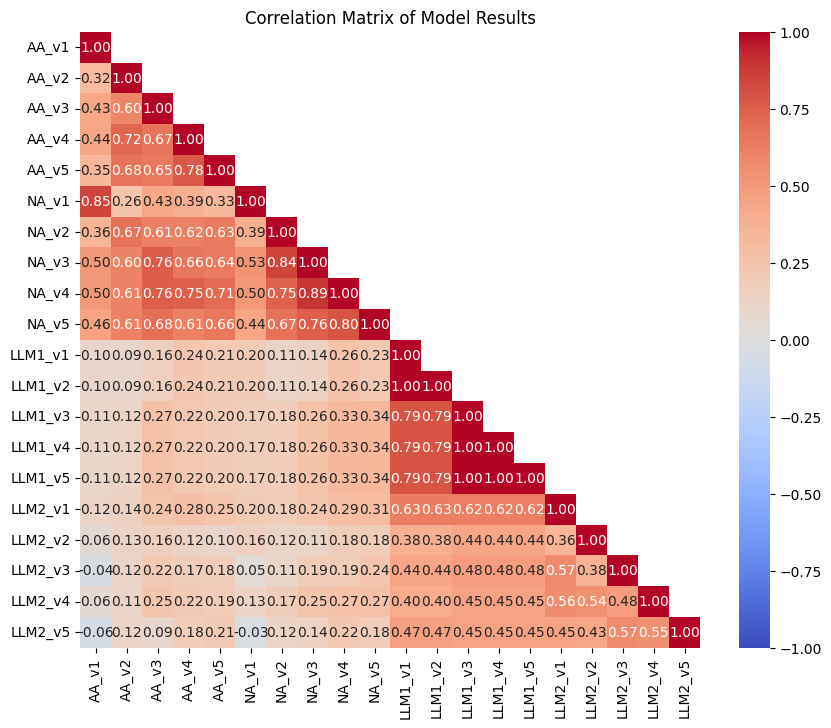

In [9]:
# Generate a heatmap

# Create a mask for the diagonal
#mask = np.eye(corr.shape[0], dtype=bool)

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # lower triangle is True, upper is False

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, mask=mask)
plt.title('Correlation Matrix of Model Results')
plt.savefig("model_results_correlation_matrix.png", dpi=300, bbox_inches='tight')
plt.show() 

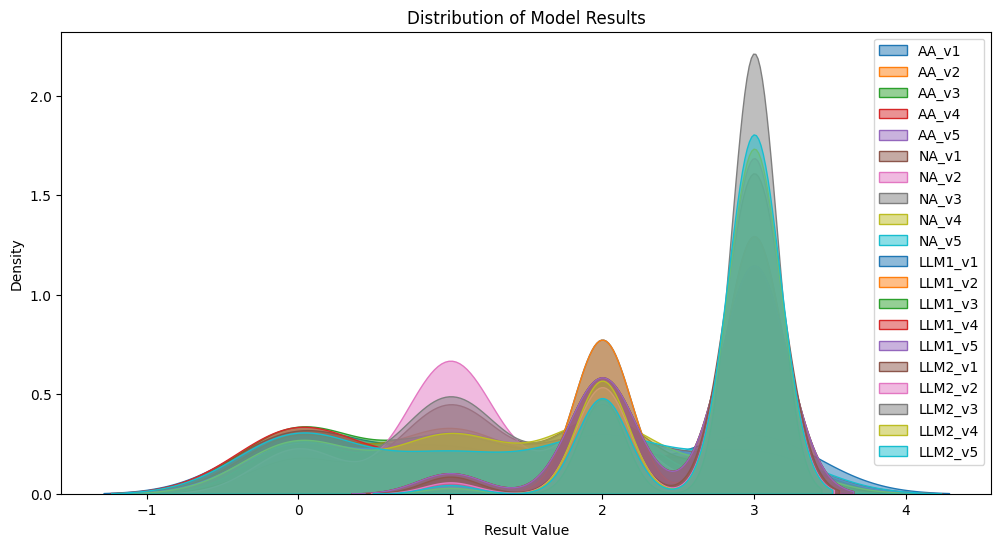

In [10]:
# Plot the distribution of results for each model
plt.figure(figsize=(12, 6))
for column in results.drop(columns = columns_to_drop).columns:
    sns.kdeplot(results[column], label=column, fill=True, alpha=0.5)
plt.title('Distribution of Model Results')
plt.xlabel('Result Value')
plt.ylabel('Density')
plt.legend()
plt.savefig("model_results_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

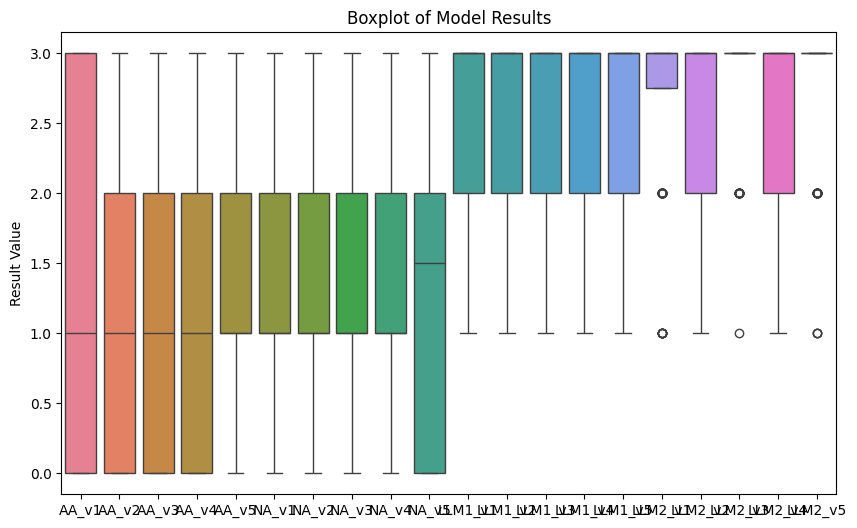

In [11]:

# Boxplot to visualize the spread and outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=results.drop(columns = columns_to_drop))
plt.title('Boxplot of Model Results')
plt.ylabel('Result Value')
plt.savefig("result_value.png", dpi=300, bbox_inches='tight')
plt.show()  

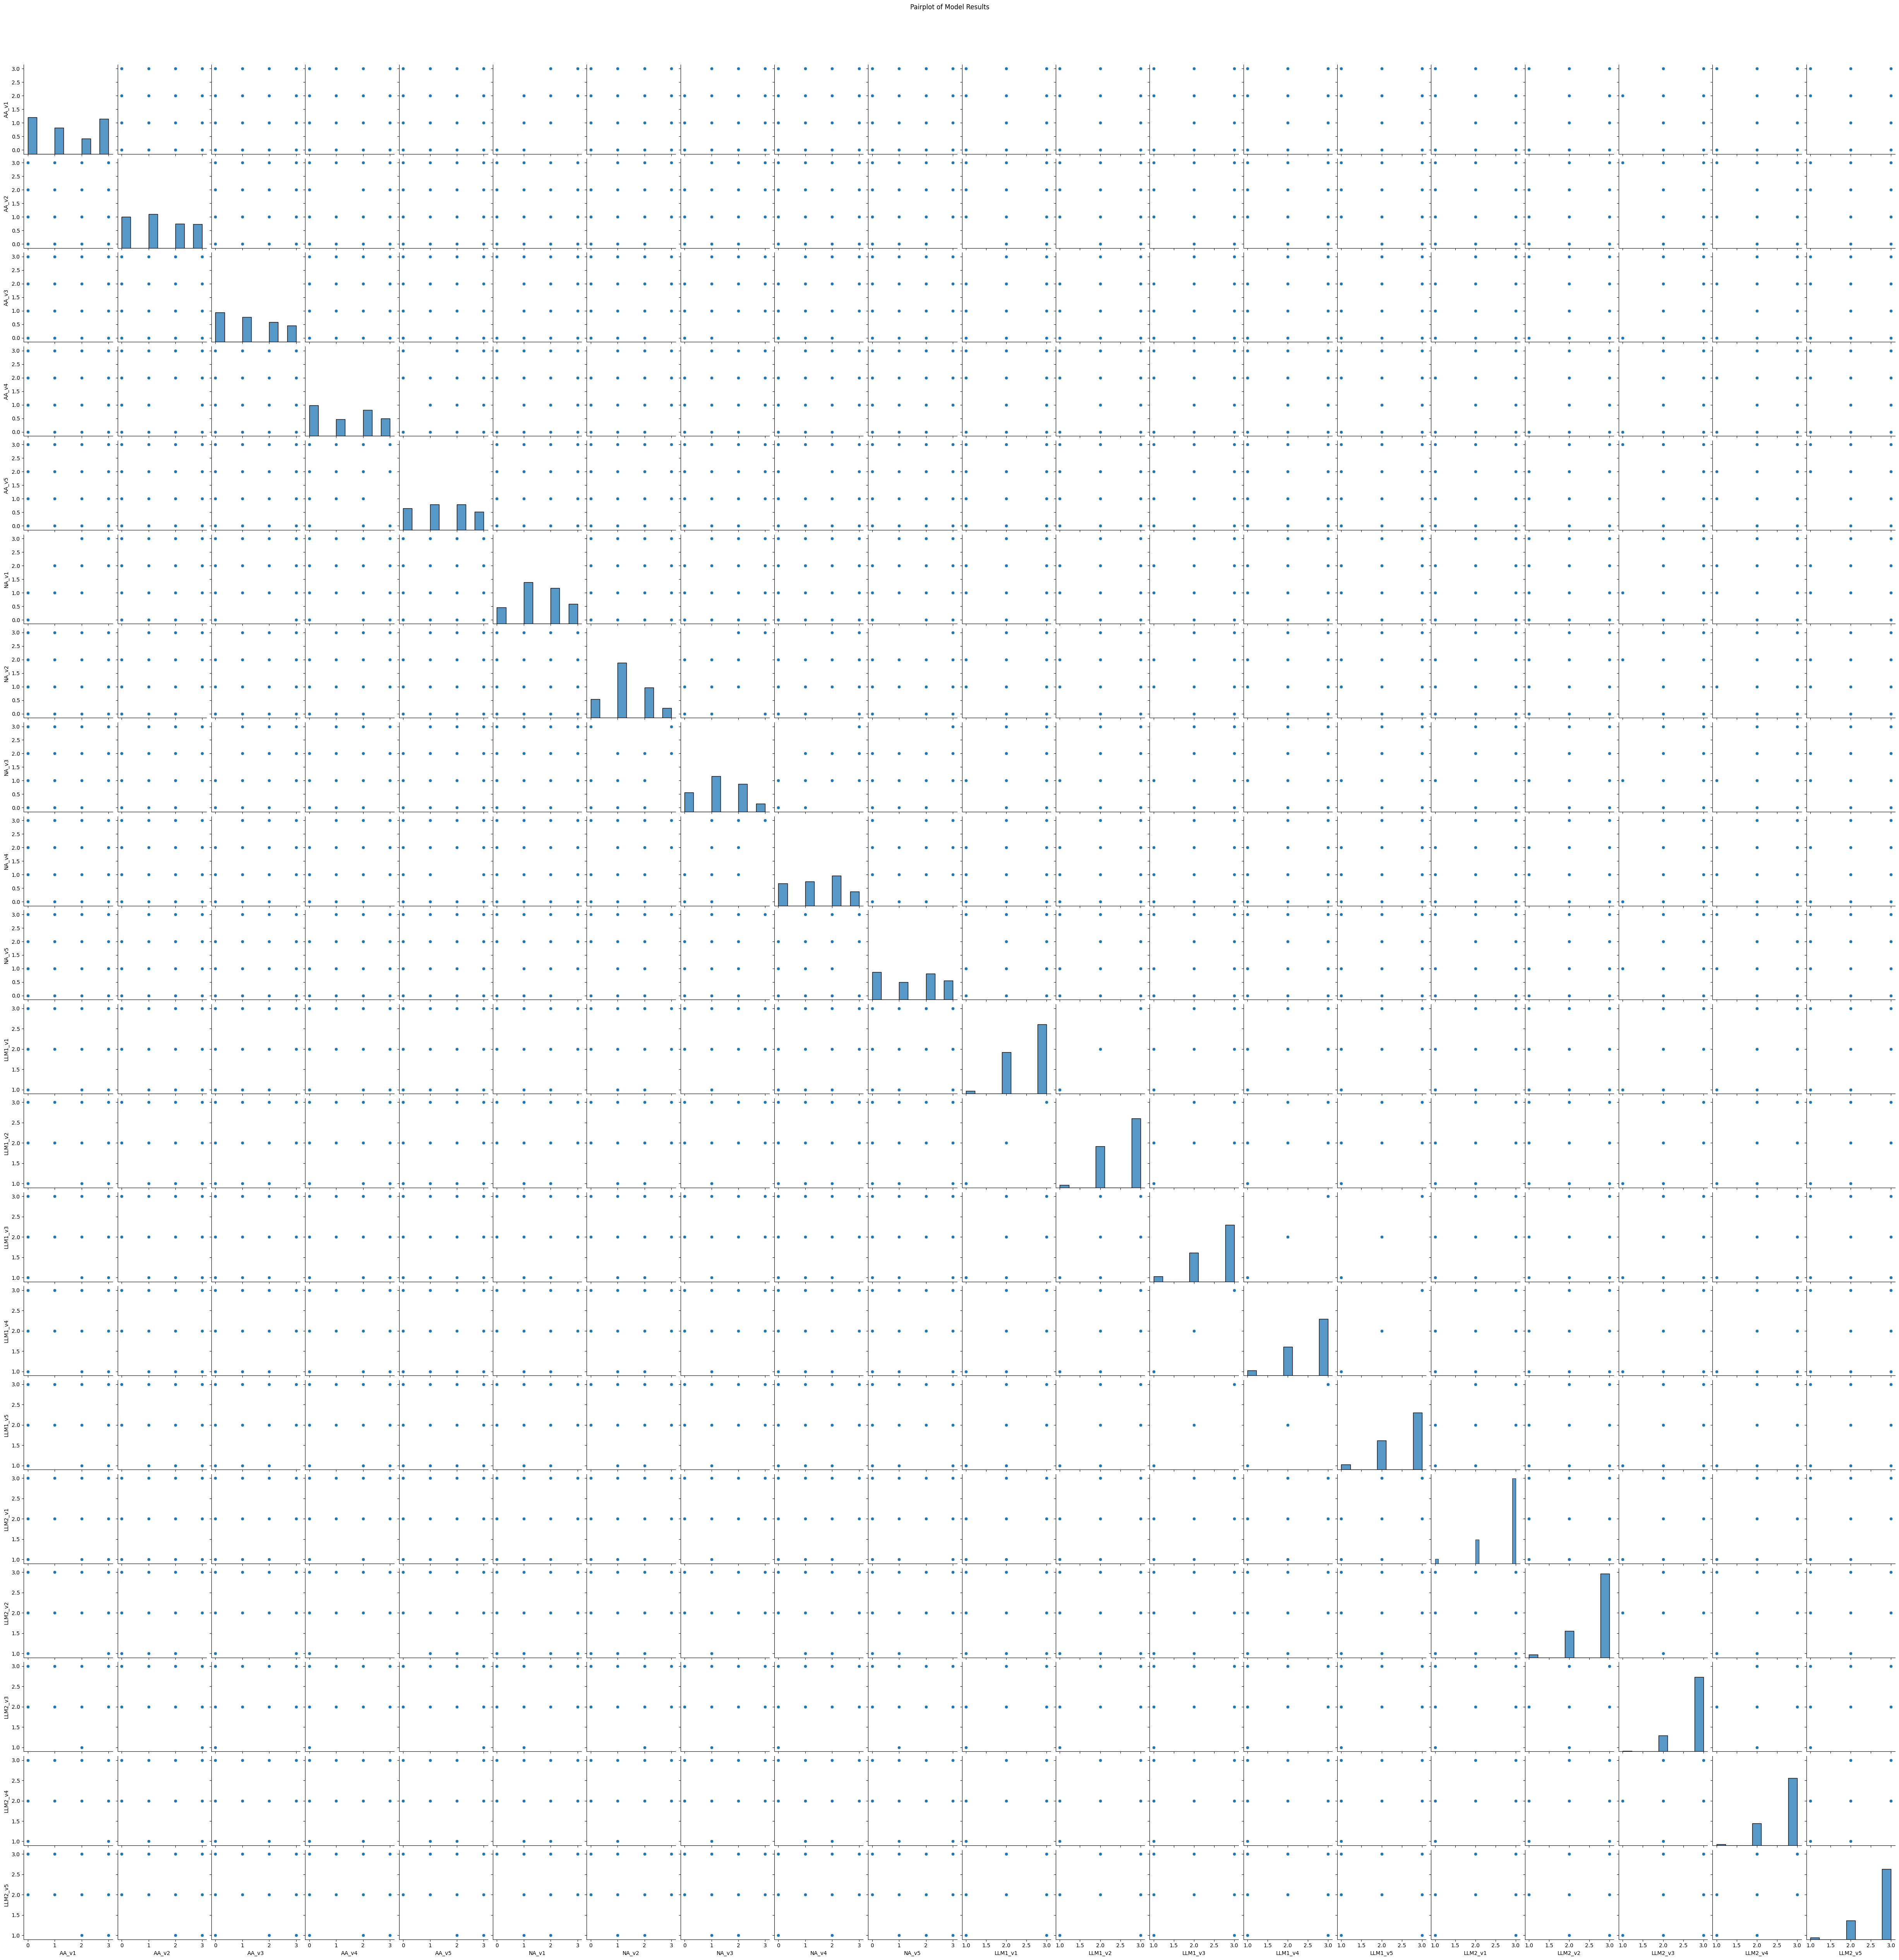

In [12]:
# Pairplot to visualize relationships between models
sns.pairplot(results.drop(columns = columns_to_drop))
plt.suptitle('Pairplot of Model Results', y=1.02)
plt.savefig("pairplot_model_results.png", dpi=300, bbox_inches='tight')
plt.show()

In [13]:

# Summary statistics
summary_stats = results.describe()
summary_stats.T

,count,mean,std,min,25%,50%,75%,max
question,200.0,5.50000,2.879489,1.0,3.00,5.5,8.0,10.0
AA_v1,200.0,1.43000,1.233983,0.0,0.00,1.0,3.0,3.0
AA_v2,200.0,1.36000,1.098377,0.0,0.00,1.0,2.0,3.0
AA_v3,160.0,1.25625,1.100297,0.0,0.00,1.0,2.0,3.0
AA_v4,160.0,1.33750,1.137621,0.0,0.00,1.0,2.0,3.0
AA_v5,160.0,1.44375,1.062493,0.0,1.00,1.0,2.0,3.0
NA_v1,200.0,1.52000,0.945553,0.0,1.00,1.0,2.0,3.0
NA_v2,200.0,1.27000,0.837020,0.0,1.00,1.0,2.0,3.0
NA_v3,160.0,1.26875,0.895284,0.0,1.00,1.0,2.0,3.0
NA_v4,160.0,1.40000,1.023006,0.0,1.00,1.0,2.0,3.0


In [14]:
res_anova = results.dropna()
res_anova.drop(columns=columns_to_drop, inplace=True, errors='ignore')

C:\Users\alexa\AppData\Local\Temp\ipykernel_20360\204835242.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  res_anova.drop(columns=columns_to_drop, inplace=True, errors='ignore')


In [15]:
res_anova

,AA_v1,AA_v2,AA_v3,AA_v4,AA_v5,NA_v1,NA_v2,NA_v3,NA_v4,NA_v5,LLM1_v1,LLM1_v2,LLM1_v3,LLM1_v4,LLM1_v5,LLM2_v1,LLM2_v2,LLM2_v3,LLM2_v4,LLM2_v5
key,,,,,,,,,,,,,,,,,,,,
gpt-3.5-turbo_US285851_Q28,0,0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,3,3,2.0,2.0,2.0,3,2,3.0,3.0,3.0
gpt-3.5-turbo_US285851_Q29,0,0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,2,2,2.0,2.0,2.0,3,3,3.0,3.0,3.0
gpt-3.5-turbo_US285851_Q30,0,0,0.0,0.0,0.0,1,0,0.0,0.0,0.0,2,2,2.0,2.0,2.0,2,3,3.0,3.0,2.0
gpt-3.5-turbo_US285851_Q31,2,2,0.0,2.0,2.0,2,1,0.0,0.0,0.0,3,3,2.0,2.0,2.0,3,3,3.0,3.0,3.0
gpt-3.5-turbo_US285851_Q32,0,2,2.0,2.0,2.0,1,0,0.0,0.0,0.0,3,3,3.0,3.0,3.0,2,3,3.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
qwen3_US37581_Q23,1,2,1.0,3.0,3.0,2,2,2.0,3.0,2.0,3,3,3.0,3.0,3.0,3,3,3.0,3.0,3.0
qwen3_US37581_Q24,1,0,0.0,0.0,0.0,1,1,1.0,1.0,0.0,3,3,3.0,3.0,3.0,3,3,3.0,3.0,3.0
qwen3_US37581_Q25,2,3,3.0,2.0,2.0,2,2,2.0,2.0,2.0,3,3,3.0,3.0,3.0,3,3,3.0,3.0,3.0


In [16]:

# Perform ANOVA test to see if there are significant differences between models
anova_results = stats.f_oneway(*(res_anova[col] for col in res_anova.columns))
print(f'ANOVA F-statistic: {anova_results.statistic}, p-value: {anova_results.pvalue}')
# If p-value < 0.05, we reject the null hypothesis and conclude that there are significant differences between model results
# If p-value < 0.05, we reject the null hypothesis and conclude that there are significant differences between model results
if anova_results.pvalue < 0.05:
    print("Significant differences exist between model results.")
else:
    print("No significant differences found between model results.")

ANOVA F-statistic: 104.1236439955325, p-value: 3.7956554e-316
Significant differences exist between model results.


In [17]:
# Concordance tests between judges
from scipy.stats import kendalltau, spearmanr
# Calculate Kendall's Tau and Spearman's Rho for each pair of models
model_names = results.drop(columns = columns_to_drop).columns
for i in range(len(model_names)):
    for j in range(i + 1, len(model_names)):
        kendall_corr, kendall_p = kendalltau(results[model_names[i]], results[model_names[j]])
        spearman_corr, spearman_p = spearmanr(results[model_names[i]], results[model_names[j]])
        print(f'Kendall Tau between {model_names[i]} and {model_names[j]}: {kendall_corr}, p-value: {kendall_p}')
        print(f'Spearman Rho between {model_names[i]} and {model_names[j]}: {spearman_corr}, p-value: {spearman_p}')
# If p-value < 0.05, we reject the null hypothesis and conclude that there is a significant correlation between the two models
        if kendall_p < 0.05:
            print(f"Significant Kendall correlation exists between {model_names[i]} and {model_names[j]}.")
        else:
            print(f"No significant Kendall correlation found between {model_names[i]} and {model_names[j]}.")
        if spearman_p < 0.05:
            print(f"Significant Spearman correlation exists between {model_names[i]} and {model_names[j]}.")
        else:
            print(f"No significant Spearman correlation found between {model_names[i]} and {model_names[j]}.")          

Kendall Tau between AA_v1 and AA_v2: 0.26748638183971984, p-value: 7.130698238757776e-06
Spearman Rho between AA_v1 and AA_v2: 0.3201226088328352, p-value: 3.818437356765476e-06
Significant Kendall correlation exists between AA_v1 and AA_v2.
Significant Spearman correlation exists between AA_v1 and AA_v2.
Kendall Tau between AA_v1 and AA_v3: nan, p-value: nan
Spearman Rho between AA_v1 and AA_v3: nan, p-value: nan
No significant Kendall correlation found between AA_v1 and AA_v3.
No significant Spearman correlation found between AA_v1 and AA_v3.
Kendall Tau between AA_v1 and AA_v4: nan, p-value: nan
Spearman Rho between AA_v1 and AA_v4: nan, p-value: nan
No significant Kendall correlation found between AA_v1 and AA_v4.
No significant Spearman correlation found between AA_v1 and AA_v4.
Kendall Tau between AA_v1 and AA_v5: nan, p-value: nan
Spearman Rho between AA_v1 and AA_v5: nan, p-value: nan
No significant Kendall correlation found between AA_v1 and AA_v5.
No significant Spearman corr

In [18]:

# Concordance  agreement  between 2 judges
from sklearn.metrics import cohen_kappa_score
# Calculate Cohen's Kappa for each pair of models
model_names = res_anova.columns
for i in range(len(model_names)):
    for j in range(i + 1, len(model_names)):
        kappa = cohen_kappa_score(res_anova[model_names[i]], res_anova[model_names[j]])
        print(f"Cohen's Kappa between {model_names[i]} and {model_names[j]}: {kappa}")
        if kappa > 0.75:
            print(f"Excellent agreement between {model_names[i]} and {model_names[j]}.")
        elif kappa > 0.4:
            print(f"Moderate agreement between {model_names[i]} and {model_names[j]}.")
        else:
            print(f"Weak agreement between {model_names[i]} and {model_names[j]}.")

Cohen's Kappa between AA_v1 and AA_v2: 0.12308174130911365
Weak agreement between AA_v1 and AA_v2.
Cohen's Kappa between AA_v1 and AA_v3: 0.22895605259022578
Weak agreement between AA_v1 and AA_v3.
Cohen's Kappa between AA_v1 and AA_v4: 0.24277095901809864
Weak agreement between AA_v1 and AA_v4.
Cohen's Kappa between AA_v1 and AA_v5: 0.1590663162776318
Weak agreement between AA_v1 and AA_v5.
Cohen's Kappa between AA_v1 and NA_v1: 0.3554235068989827
Weak agreement between AA_v1 and NA_v1.
Cohen's Kappa between AA_v1 and NA_v2: 0.1530082459533747
Weak agreement between AA_v1 and NA_v2.
Cohen's Kappa between AA_v1 and NA_v3: 0.1895861824444106
Weak agreement between AA_v1 and NA_v3.
Cohen's Kappa between AA_v1 and NA_v4: 0.1842561435709188
Weak agreement between AA_v1 and NA_v4.
Cohen's Kappa between AA_v1 and NA_v5: 0.11928130030638207
Weak agreement between AA_v1 and NA_v5.
Cohen's Kappa between AA_v1 and LLM1_v1: -0.028832192491184294
Weak agreement between AA_v1 and LLM1_v1.
Cohen's K

In [19]:
agg = aggregate_groups(results, agg="mode")
agg

,model,project,question,AA_Total,NA_Total,LLM1_Total,LLM2_Total
key,,,,,,,
deepseek-r1_US285851_Q28,deepseek-r1,US285851,4,0.0,1.0,3.0,3.0
deepseek-r1_US285851_Q29,deepseek-r1,US285851,5,0.0,1.0,2.0,1.0
deepseek-r1_US285851_Q30,deepseek-r1,US285851,2,0.0,0.0,3.0,3.0
deepseek-r1_US285851_Q31,deepseek-r1,US285851,6,1.0,1.0,2.0,2.0
deepseek-r1_US285851_Q32,deepseek-r1,US285851,1,3.0,2.0,2.0,2.0
...,...,...,...,...,...,...,...
qwen3_US37581_Q23,qwen3,US37581,8,1.0,2.0,3.0,3.0
qwen3_US37581_Q24,qwen3,US37581,3,0.0,1.0,3.0,3.0
qwen3_US37581_Q25,qwen3,US37581,10,2.0,2.0,3.0,3.0


## Weighted Cohen Kappa (judges < 3) & Kendall W & Krippendorff Alpha (judges > 2)

In [20]:
def concordance_computation( dataset, mode = "question", columns_to_exclude = [], ndigits=3 ):
    evaluation_mode = mode # "question", "model", "project"
    records_q_all = []
    df = pd.DataFrame( dataset.dropna() )
    judges = dataset.drop( columns=columns_to_exclude).columns.to_list() # ["AA", "NA", "LLMx"]
    n_judges = len(judges)
    for q in sorted(df[evaluation_mode].unique()):
        df_q = df[df[evaluation_mode] == q]

        group_all = df_q[judges]
    
        median_scores = group_all.median()
        mode_scores = group_all.apply(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)

        if n_judges > 2:
            kendall = compute_kendall_w(group_all)
            alpha = krippendorff.alpha(reliability_data=group_all.T, level_of_measurement='ordinal')
            #alpha = safe_krippendorff_alpha(group_all)
            record = {"Id": q, "Kendall_W": round(kendall, ndigits), "Krippendorff_alpha": round(alpha, ndigits)}
        else:
            cohen = cohen_kappa_score( group_all[judges[0]], group_all[judges[1]], weights="linear" )
            record = {"Id": q, "Cohen_kappa": round(cohen, ndigits)}
            
        for col in df_q[judges].columns:
            record[f"{col}_median"] = median_scores[col]
            record[f"{col}_mode"] = mode_scores[col]
            
        records_q_all.append(record)
    return pd.DataFrame(records_q_all).round(ndigits)
        

In [21]:
llms_used = ["LLM1_Total","LLM2_Total"]
professional_judges = ["AA_Total","NA_Total"]

## Concordance between the 2 professionals (Project Managers)

In [22]:

q_results = concordance_computation( agg, mode="question", columns_to_exclude = columns_to_drop + llms_used , ndigits=3)
m_results = concordance_computation( agg, mode="model", columns_to_exclude = columns_to_drop + llms_used, ndigits=3)
p_results = concordance_computation( agg, mode="project", columns_to_exclude = columns_to_drop + llms_used, ndigits=3)
plot_dataframes_side_by_side( [q_results, m_results, p_results], ["Per Question Concordance", "Per Model Concordance", "Per Project Concordance"] )

,Id,Cohen_kappa,AA_Total_median,AA_Total_mode,NA_Total_median,NA_Total_mode
0,1,0.559000,2.500000,3.000000,2.000000,2.000000
1,2,0.279000,0.000000,0.000000,0.000000,0.000000
2,3,0.600000,0.000000,0.000000,0.500000,0.000000
3,4,0.355000,3.000000,3.000000,2.000000,2.000000
4,5,0.286000,0.000000,0.000000,1.000000,1.000000
5,6,0.257000,1.000000,1.000000,1.000000,1.000000
6,7,0.236000,2.000000,2.000000,2.000000,2.000000
7,8,0.389000,1.000000,1.000000,1.500000,1.000000
8,9,0.695000,1.000000,1.000000,2.000000,2.000000
9,10,0.412000,2.000000,1.000000,2.000000,2.000000


## Concordance between the 2 LLMs

In [23]:
agg.query("question==2")[["LLM1_Total", "LLM2_Total"]]

,LLM1_Total,LLM2_Total
key,,
deepseek-r1_US285851_Q30,3.0,3.0
deepseek-r1_US293949_Q40,2.0,1.0
deepseek-r1_US37581_285851_293949_Q50,3.0,3.0
deepseek-r1_US37581_Q20,2.0,2.0
gpt-3.5-turbo_US285851_Q30,2.0,3.0
gpt-3.5-turbo_US293949_Q40,2.0,2.0
gpt-3.5-turbo_US37581_285851_293949_Q50,2.0,3.0
gpt-3.5-turbo_US37581_Q20,2.0,3.0
gpt-4o_US285851_Q30,2.0,3.0


In [24]:
q_results = concordance_computation( agg, mode="question", columns_to_exclude = columns_to_drop + professional_judges , ndigits=3)
m_results = concordance_computation( agg, mode="model", columns_to_exclude = columns_to_drop + professional_judges, ndigits=3)
p_results = concordance_computation( agg, mode="project", columns_to_exclude = columns_to_drop + professional_judges, ndigits=3)
plot_dataframes_side_by_side( [q_results, m_results, p_results], ["Per Question Concordance", "Per Model Concordance", "Per Project Concordance"] )

c:\Python\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Python\Lib\site-packages\sklearn\metrics\_classification.py:897: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)
c:\Python\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Python\Lib\site-packages\sklearn\metrics\_classification.py:897: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)


,Id,Cohen_kappa,LLM1_Total_median,LLM1_Total_mode,LLM2_Total_median,LLM2_Total_mode
0,1,0.549000,2.000000,2.000000,2.000000,2.000000
1,2,0.245000,2.000000,2.000000,2.000000,2.000000
2,3,0.552000,2.000000,2.000000,3.000000,3.000000
3,4,0.300000,2.500000,2.000000,3.000000,3.000000
4,5,0.459000,2.000000,2.000000,3.000000,3.000000
5,6,0.149000,2.000000,2.000000,3.000000,3.000000
6,7,0.000000,3.000000,3.000000,3.000000,3.000000
7,8,nan,3.000000,3.000000,3.000000,3.000000
8,9,-0.087000,3.000000,3.000000,3.000000,3.000000
9,10,nan,3.000000,3.000000,3.000000,3.000000


In [25]:
p_results

,Id,Cohen_kappa,LLM1_Total_median,LLM1_Total_mode,LLM2_Total_median,LLM2_Total_mode
0,US285851,0.303,3.0,3.0,3.0,3.0
1,US293949,0.657,3.0,3.0,3.0,3.0
2,US37581,0.408,3.0,3.0,3.0,3.0
3,US37581_285851_293949,0.531,3.0,3.0,3.0,3.0


In [26]:
agg.query("question==10")["AA_Total"]

key
deepseek-r1_US285851_Q35                   1.0
deepseek-r1_US293949_Q45                   1.0
deepseek-r1_US37581_285851_293949_Q55      1.0
deepseek-r1_US37581_Q25                    2.0
gpt-3.5-turbo_US285851_Q35                 3.0
gpt-3.5-turbo_US293949_Q45                 3.0
gpt-3.5-turbo_US37581_285851_293949_Q55    3.0
gpt-3.5-turbo_US37581_Q25                  2.0
gpt-4o_US285851_Q35                        3.0
gpt-4o_US293949_Q45                        3.0
gpt-4o_US37581_285851_293949_Q55           2.0
gpt-4o_US37581_Q25                         1.0
llama3.2_US285851_Q35                      2.0
llama3.2_US293949_Q45                      1.0
llama3.2_US37581_285851_293949_Q55         1.0
llama3.2_US37581_Q25                       1.0
qwen3_US285851_Q35                         2.0
qwen3_US293949_Q45                         3.0
qwen3_US37581_285851_293949_Q55            3.0
qwen3_US37581_Q25                          2.0
Name: AA_Total, dtype: float64

In [27]:
from sklearn.metrics import cohen_kappa_score

# Example: agreement between AA_total and NA_total
kappa = cohen_kappa_score(agg.query("question==1")["AA_Total"], agg.query("question==1")["NA_Total"], weights="linear")
print("Cohen’s Kappa:", kappa)

Cohen’s Kappa: 0.5588235294117647


In [28]:
from sklearn.metrics import cohen_kappa_score

# Example: agreement between AA_total and NA_total
kappa = cohen_kappa_score(agg.query("question==1")["AA_Total"], agg.query("question==1")["LLM1_Total"], weights="linear")
print("Cohen’s Kappa:", kappa)

Cohen’s Kappa: -0.0775862068965516


In [29]:
from sklearn.metrics import cohen_kappa_score

# Example: agreement between AA_total and NA_total
kappa = cohen_kappa_score(agg.query("question==1")["NA_Total"], agg.query("question==1")["LLM1_Total"], weights="linear")
print("Cohen’s Kappa:", kappa)

Cohen’s Kappa: 0.14414414414414412


## Concordance between all (Professionals + LLMs)

In [30]:
#llm_judge = ['LLM_v1','LLM_v2','LLM_v3','LLM_v4','LLM_v5']

q_results = concordance_computation( agg, mode="question", columns_to_exclude = columns_to_drop, ndigits=3)
m_results = concordance_computation( agg, mode="model", columns_to_exclude = columns_to_drop, ndigits=3)
p_results = concordance_computation( agg, mode="project", columns_to_exclude = columns_to_drop, ndigits=3)
plot_dataframes_side_by_side( [q_results, m_results, p_results], ["Per Question Concordance", "Per Model Concordance", "Per Project Concordance"] )

,Id,Kendall_W,Krippendorff_alpha,AA_Total_median,AA_Total_mode,NA_Total_median,NA_Total_mode,LLM1_Total_median,LLM1_Total_mode,LLM2_Total_median,LLM2_Total_mode
0,1,0.285000,0.107000,2.500000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
1,2,0.122000,-0.231000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,2.000000,2.000000
2,3,0.283000,-0.079000,0.000000,0.000000,0.500000,0.000000,2.000000,2.000000,3.000000,3.000000
3,4,0.282000,0.050000,3.000000,3.000000,2.000000,2.000000,2.500000,2.000000,3.000000,3.000000
4,5,0.274000,-0.186000,0.000000,0.000000,1.000000,1.000000,2.000000,2.000000,3.000000,3.000000
5,6,0.316000,-0.090000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,3.000000,3.000000
6,7,0.146000,-0.133000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,3.000000
7,8,0.153000,-0.115000,1.000000,1.000000,1.500000,1.000000,3.000000,3.000000,3.000000,3.000000
8,9,0.331000,0.004000,1.000000,1.000000,2.000000,2.000000,3.000000,3.000000,3.000000,3.000000
9,10,0.162000,-0.089000,2.000000,1.000000,2.000000,2.000000,3.000000,3.000000,3.000000,3.000000


### Export any Dataframe to Latex

In [31]:
# Export a dataframe to Latex with only 3 decimal spaces
# Upload the file "concordance_per_question_all.tex" to your project and use it like:     \input{concordance_per_question_all.tex}
# Reference the table in your text like:     \ref{tab:per_question_concordance_all_judges}
# Repeat for any other dataframe/table you want to export to Latex
q_results.to_latex("concordance_per_question_all.tex", caption="Per Question Concordance (All Judges)", label="tab:per_question_concordance_all_judges", float_format="%.3f", index=False)

## ✅ Summary:

### Cohen’s Kappa → 2 raters.

### Fleiss’ Kappa → multiple raters.

### Kendall’s W → ranks / ordinal ratings.

### Krippendorff’s Alpha → flexible, best for research-quality agreement.